<a href="https://colab.research.google.com/github/AmandaBfa/FundamentosIV_Metodo_de_Intera-o_de_ponto_fixo/blob/main/m%C3%A9todo_de_Intera%C3%A7%C3%A3o_de_ponto_fixo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Digite o chute inicial (x0): 1


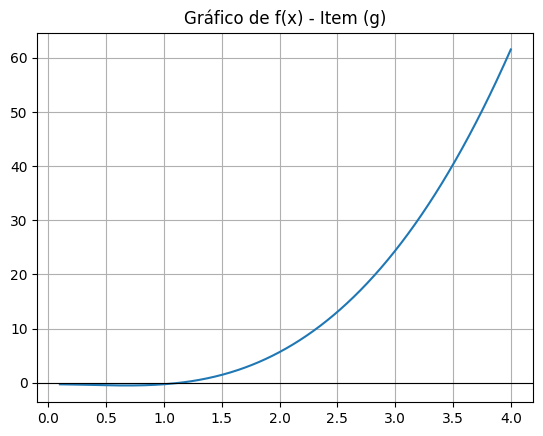




********************************************************************************
Método do Ponto Fixo - Item (g)
********************************************************************************
  i           xk        f(xk)        g(xk)         ERRO
********************************************************************************
  1     1.000000    -0.283474     1.086749          ---
  2     1.086749    -0.123929     1.120657     0.086749
  3     1.120657    -0.047494     1.133124     0.033909
  4     1.133124    -0.017298     1.137597     0.012467
  5     1.137597    -0.006184     1.139187     0.004473
  6     1.139187    -0.002196     1.139751     0.001591
  7     1.139751    -0.000778     1.139951     0.000564
********************************************************************************
Resultados Finais:
Valor da Raiz: 1.139751
Erro Final: 0.000564
Número de Iterações: 7
f(raiz) = -0.000778


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# a) f(x) = 2ln(3-cos(x)) - 3x^x + 5sen(x)
# def f(x): return 2*np.log(3 - np.cos(x)) - 3*(x**x) + 5*np.sin(x)
# def g(x): return ( (2*np.log(3 - np.cos(x)) + 5*np.sin(x)) / 3 )**(1/x)
# titulo = "Item (a)"

# b) f(x) = x^2 - 10ln(x) - 5
# def f(x): return x**2 - 10*np.log(x) - 5
# def g(x): return np.sqrt(10*np.log(x) + 5)
# titulo = "Item (b): f(x) = x^2 - 10ln(x) - 5"

# c) f(x) = x^3 - e^(2x) + 3
# def f(x): return x**3 - np.exp(2*x) + 3
# def g(x): return np.log(x**3 + 3) / 2
# titulo = "Item (c)"

# d) f(x) = x + log(x)
# def f(x): return x + np.log10(x)
# def g(x): return 10**(-x)
# titulo = "Item (d)"

# e) f(x) = 2x^3 + x^2 - 2
# def f(x): return 2*x**3 + x**2 - 2
# def g(x): return np.sqrt(2 / (2*x + 1))
# titulo = "Item (e)"

# f) f(x) = sen(x) - ln(x)
# def f(x): return np.sin(x) - np.log(x)
# def g(x): return np.exp(np.sin(x))
# titulo = "Item (f)"

# g) f(x) = e^cos(x) + x^3 - 3
def f(x): return np.exp(np.cos(x)) + x**3 - 3
def g(x): return np.cbrt(3 - np.exp(np.cos(x)))
titulo = "Item (g)"

def ponto_fixo(x0, TOL, itermax):
    i = 1
    xk = x0

    try:
        val_f = f(xk)
    except:
        print("Erro de domínio no chute inicial.")
        return None

    print("\n" * 2)
    print("*" * 80)
    print(f"Método do Ponto Fixo - {titulo}")
    print("*" * 80)
    print(f"{'i':>3} {'xk':>12} {'f(xk)':>12} {'g(xk)':>12} {'ERRO':>12}")
    print("*" * 80)

    print(f"{1:3d} {xk:12.6f} {f(xk):12.6f} {g(xk):12.6f} {'---':>12}")

    ERRO = 1000

    while ERRO >= TOL and i < itermax:
        xk_old = xk

        try:
            xk = g(xk_old)
            i += 1
            ERRO = abs(xk - xk_old)
            print(f"{i:3d} {xk:12.6f} {f(xk):12.6f} {g(xk):12.6f} {ERRO:12.6f}")
        except Exception as e:
            print(f"Erro matemático durante a iteração: {e}")
            break

    return [xk, ERRO, i]

x0 = float(input("Digite o chute inicial (x0): "))
TOL = 0.001
itermax = 40

x_plot = np.linspace(0.1, 4, 400)
plt.plot(x_plot, f(x_plot), label='f(x)')
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f"Gráfico de f(x) - {titulo}")
plt.grid(True)
plt.show()

res = ponto_fixo(x0, TOL, itermax)

if res is not None:
    print("*" * 80)
    print("Resultados Finais:")
    print(f"Valor da Raiz: {res[0]:.6f}")
    print(f"Erro Final: {res[1]:.6f}")
    print(f"Número de Iterações: {res[2]}")
    print(f"f(raiz) = {f(res[0]):.6f}")